In [1]:
# ============================================================
# BLOCK 1 — Imports
# ============================================================
import os
import re
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, f1_score

print("All imports successful")

# ── Device ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f"Device : {device}")

All imports successful
Device : cpu


In [2]:
# ============================================================
# BLOCK 2 — Load All Models
# ============================================================

# ── SVM ─────────────────────────────────────────────────────
with open('models/svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)
print("✓ SVM loaded")

# ── Random Forest ────────────────────────────────────────────
with open('models/rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
print("✓ Random Forest loaded")

# ── TF-IDF + Scaler (for SVM / RF / LSTM) ───────────────────
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('models/robust_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print("✓ TF-IDF vectorizer loaded")
print("✓ RobustScaler loaded")

# ── LSTM ─────────────────────────────────────────────────────
lstm_checkpoint = torch.load('models/lstm_model.pt',
                              map_location=device)

# Rebuild LSTM architecture
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, meta_dim,
                 pad_idx, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 + meta_dim,
                             num_classes)

    def forward(self, sequences, meta):
        embedded = self.dropout(self.embedding(sequences))
        _, (hidden, _) = self.lstm(embedded)
        hidden_fwd = hidden[-2]
        hidden_bwd = hidden[-1]
        combined   = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        combined   = self.dropout(combined)
        combined   = torch.cat([combined, meta], dim=1)
        return self.fc(combined)

lstm_model = LSTMClassifier(
    vocab_size = lstm_checkpoint['vocab_size'],
    embed_dim  = lstm_checkpoint['embed_dim'],
    hidden_dim = lstm_checkpoint['hidden_dim'],
    num_layers = lstm_checkpoint['num_layers'],
    num_classes= lstm_checkpoint['num_classes'],
    meta_dim   = lstm_checkpoint['meta_dim'],
    pad_idx    = lstm_checkpoint['pad_idx'],
    dropout    = lstm_checkpoint['dropout']
).to(device)
lstm_model.load_state_dict(lstm_checkpoint['model_state_dict'])
lstm_model.eval()
word2idx    = lstm_checkpoint['word2idx']
MAX_SEQ_LEN = lstm_checkpoint['max_seq_len']
PAD_IDX     = lstm_checkpoint['pad_idx']
UNK_IDX     = 1
print("✓ LSTM loaded")

# ── BERT ─────────────────────────────────────────────────────
from transformers import BertTokenizer, BertModel

bert_checkpoint = torch.load('models/bert_classifier.pt',
                              map_location=device)

class BertHybridClassifier(nn.Module):
    def __init__(self, num_classes, meta_dim, dropout=0.3):
        super(BertHybridClassifier, self).__init__()
        self.bert       = BertModel.from_pretrained(
                            'models/bert_base')
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(768 + meta_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, meta):
        outputs    = self.bert(input_ids=input_ids,
                               attention_mask=attention_mask)
        cls_output = self.dropout(outputs.pooler_output)
        combined   = torch.cat([cls_output, meta], dim=1)
        return self.classifier(combined)

bert_model = BertHybridClassifier(
    num_classes = bert_checkpoint['num_classes'],
    meta_dim    = bert_checkpoint['meta_dim'],
    dropout     = bert_checkpoint['dropout']
).to(device)
bert_model.load_state_dict(
    bert_checkpoint['classifier_state_dict'])
bert_model.eval()

bert_tokenizer = BertTokenizer.from_pretrained(
    'models/bert_tokenizer')
BERT_MAX_LEN = bert_checkpoint['max_len']
print("✓ BERT loaded")

# ── SHAP values ──────────────────────────────────────────────
with open('models/shap_values.pkl', 'rb') as f:
    shap_saved = pickle.load(f)

shap_raw     = np.array(shap_saved['shap_values'])  # (200,50006,2)
shap_fake    = shap_raw[:, :, 0]   # (200, 50006)
shap_real    = shap_raw[:, :, 1]   # (200, 50006)
shap_X       = shap_saved['X_explain']
shap_y       = shap_saved['y_explain']
shap_idx     = shap_saved['explain_idx']
print("✓ SHAP values loaded")

print("\n" + "="*45)
print("ALL MODELS LOADED SUCCESSFULLY")
print("="*45)

✓ SVM loaded
✓ Random Forest loaded
✓ TF-IDF vectorizer loaded
✓ RobustScaler loaded
✓ LSTM loaded


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3475.79it/s]


✓ BERT loaded
✓ SHAP values loaded

ALL MODELS LOADED SUCCESSFULLY


In [3]:
# ============================================================
# BLOCK 3 — Preprocessing Helpers
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words]
    return ' '.join(tokens)

def encode_and_pad(tokens, word2idx, max_len):
    indices  = [word2idx.get(t, UNK_IDX) for t in tokens]
    indices  = indices[:max_len]
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

credit_cols = ['true_counts', 'mostly_true_counts',
               'half_true_counts', 'mostly_false_counts',
               'false_counts', 'pants_on_fire_counts']
ratio_cols  = [c.replace('_counts', '_ratio')
               for c in credit_cols]

def compute_meta(df):
    """Compute credibility ratios and scale them."""
    df = df.copy()
    df['total_counts'] = df[credit_cols].sum(axis=1)
    for col in credit_cols:
        ratio = col.replace('_counts', '_ratio')
        df[ratio] = df[col] / df['total_counts']
    return scaler.transform(df[ratio_cols])

print("Preprocessing helpers ready")

Preprocessing helpers ready


In [4]:
# ============================================================
# BLOCK 4 — Single Claim Prediction Function
# ============================================================
LABEL_MAP = {0: '🔴 FAKE', 1: '🟢 REAL'}

def predict_claim(statement, justification,
                  true_c, mostly_true_c, half_true_c,
                  mostly_false_c, false_c, pants_fire_c):
    """
    Predict whether a claim is Fake or Real using all 4 models.

    Parameters
    ----------
    statement      : str  — the political claim text
    justification  : str  — fact-checker reasoning text
    true_c         : int  — speaker's true count history
    mostly_true_c  : int  — speaker's mostly-true count
    half_true_c    : int  — speaker's half-true count
    mostly_false_c : int  — speaker's mostly-false count
    false_c        : int  — speaker's false count
    pants_fire_c   : int  — speaker's pants-on-fire count
    """

    # ── Build meta features ──────────────────────────────────
    meta_df = pd.DataFrame([{
        'true_counts'         : true_c,
        'mostly_true_counts'  : mostly_true_c,
        'half_true_counts'    : half_true_c,
        'mostly_false_counts' : mostly_false_c,
        'false_counts'        : false_c,
        'pants_on_fire_counts': pants_fire_c
    }])
    meta_features = compute_meta(meta_df)  # (1, 6)

    # ── Clean + vectorize text ───────────────────────────────
    clean = clean_text(statement + ' ' + justification)
    tfidf_vec = tfidf.transform([clean])               # (1, 50000)
    X_ml = hstack([tfidf_vec,
                   csr_matrix(meta_features)])         # (1, 50006)

    results = {}

    # ── SVM prediction ───────────────────────────────────────
    svm_pred  = svm_model.predict(X_ml)[0]
    svm_prob  = svm_model.predict_proba(X_ml)[0]
    results['SVM'] = {
        'label'      : LABEL_MAP[svm_pred],
        'confidence' : f"{max(svm_prob)*100:.1f}%",
        'fake_prob'  : svm_prob[0],
        'real_prob'  : svm_prob[1]
    }

    # ── Random Forest prediction ─────────────────────────────
    rf_pred  = rf_model.predict(X_ml)[0]
    rf_prob  = rf_model.predict_proba(X_ml)[0]
    results['Random Forest'] = {
        'label'      : LABEL_MAP[rf_pred],
        'confidence' : f"{max(rf_prob)*100:.1f}%",
        'fake_prob'  : rf_prob[0],
        'real_prob'  : rf_prob[1]
    }

    # ── LSTM prediction ──────────────────────────────────────
    tokens    = clean.split()
    seq       = encode_and_pad(tokens, word2idx, MAX_SEQ_LEN)
    seq_tensor  = torch.tensor([seq],
                                dtype=torch.long).to(device)
    meta_tensor = torch.tensor(meta_features,
                                dtype=torch.float32).to(device)
    with torch.no_grad():
        lstm_out  = lstm_model(seq_tensor, meta_tensor)
        lstm_prob = torch.softmax(lstm_out, dim=1)[0].cpu().numpy()
    lstm_pred = int(np.argmax(lstm_prob))
    results['LSTM'] = {
        'label'      : LABEL_MAP[lstm_pred],
        'confidence' : f"{max(lstm_prob)*100:.1f}%",
        'fake_prob'  : lstm_prob[0],
        'real_prob'  : lstm_prob[1]
    }

    # ── BERT prediction ──────────────────────────────────────
    raw_text    = statement + ' ' + justification
    bert_enc    = bert_tokenizer(
        raw_text,
        max_length      = BERT_MAX_LEN,
        padding         = 'max_length',
        truncation      = True,
        return_tensors  = 'pt',
        add_special_tokens = True
    )
    input_ids   = bert_enc['input_ids'].to(device)
    attn_mask   = bert_enc['attention_mask'].to(device)
    meta_bert   = torch.tensor(meta_features,
                                dtype=torch.float32).to(device)
    with torch.no_grad():
        bert_out  = bert_model(input_ids, attn_mask, meta_bert)
        bert_prob = torch.softmax(bert_out, dim=1)[0].cpu().numpy()
    bert_pred = int(np.argmax(bert_prob))
    results['BERT'] = {
        'label'      : LABEL_MAP[bert_pred],
        'confidence' : f"{max(bert_prob)*100:.1f}%",
        'fake_prob'  : bert_prob[0],
        'real_prob'  : bert_prob[1]
    }

    return results


print("predict_claim() function ready")

predict_claim() function ready


Running predictions...

PREDICTION RESULTS
Claim : Under the health care law, employees could
                   be forced to pay $...
-------------------------------------------------------
Model              Prediction     Confidence  Fake%      Real%
-------------------------------------------------------
SVM                🔴 FAKE         85.5%       85.5      14.5
Random Forest      🔴 FAKE         59.7%       59.7      40.3
LSTM               🔴 FAKE         82.3%       82.3      17.7
BERT               🔴 FAKE         98.9%       98.9      1.1

Final verdict (majority vote): 🔴 FAKE
Agreement                     : 0/4 models say REAL


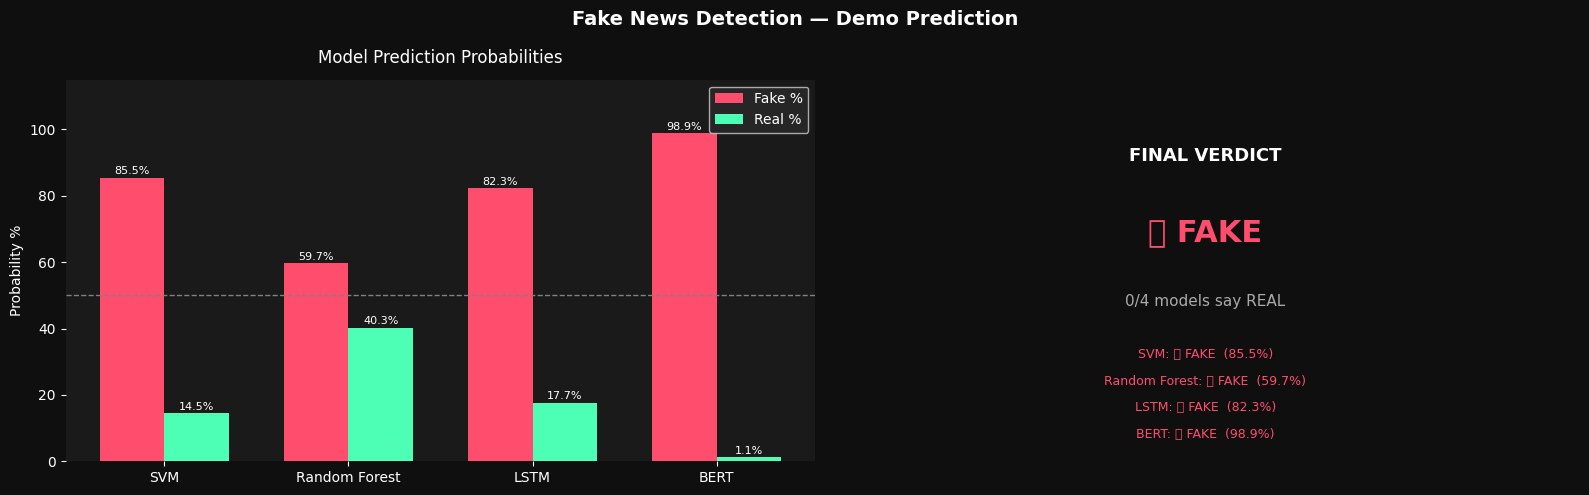

Saved as demo_prediction.png


In [5]:
# ============================================================
# BLOCK 5 — Run a Demo Prediction + Visualize
# ============================================================
# ── Enter your claim here ────────────────────────────────────
STATEMENT     = """Under the health care law, employees could
                   be forced to pay $5,000 for a health
                   insurance plan worth only $2,000."""

JUSTIFICATION = """This claim misrepresents how the health
                   care law works. The law sets limits on
                   what employees can be required to pay."""

# Speaker credibility history
# Change these to match the speaker you are testing
TRUE_COUNT         = 5
MOSTLY_TRUE_COUNT  = 8
HALF_TRUE_COUNT    = 10
MOSTLY_FALSE_COUNT = 12
FALSE_COUNT        = 15
PANTS_FIRE_COUNT   = 6

# ── Run prediction ───────────────────────────────────────────
print("Running predictions...\n")
results = predict_claim(
    statement      = STATEMENT,
    justification  = JUSTIFICATION,
    true_c         = TRUE_COUNT,
    mostly_true_c  = MOSTLY_TRUE_COUNT,
    half_true_c    = HALF_TRUE_COUNT,
    mostly_false_c = MOSTLY_FALSE_COUNT,
    false_c        = FALSE_COUNT,
    pants_fire_c   = PANTS_FIRE_COUNT
)

# ── Print results ────────────────────────────────────────────
print("="*55)
print("PREDICTION RESULTS")
print("="*55)
print(f"Claim : {STATEMENT[:80].strip()}...")
print("-"*55)
print(f"{'Model':<18} {'Prediction':<14} {'Confidence':<12}"
      f"{'Fake%':<10} {'Real%'}")
print("-"*55)
for model_name, res in results.items():
    print(f"{model_name:<18} {res['label']:<14} "
          f"{res['confidence']:<12}"
          f"{res['fake_prob']*100:<10.1f}"
          f"{res['real_prob']*100:.1f}")
print("="*55)

# ── Majority vote ────────────────────────────────────────────
votes     = [1 if '🟢' in r['label'] else 0
             for r in results.values()]
final     = '🟢 REAL' if sum(votes) >= 3 else '🔴 FAKE'
agreement = f"{sum(votes)}/4 models say REAL"
print(f"\nFinal verdict (majority vote): {final}")
print(f"Agreement                     : {agreement}")

# ── Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')

# Plot 1 — Probability bars per model
ax1 = axes[0]
ax1.set_facecolor('#1a1a1a')
model_names = list(results.keys())
fake_probs  = [results[m]['fake_prob'] * 100
               for m in model_names]
real_probs  = [results[m]['real_prob'] * 100
               for m in model_names]
x     = np.arange(len(model_names))
width = 0.35
ax1.bar(x - width/2, fake_probs, width,
        color='#ff4d6d', label='Fake %', edgecolor='none')
ax1.bar(x + width/2, real_probs, width,
        color='#4dffb4', label='Real %', edgecolor='none')
for i, (f, r) in enumerate(zip(fake_probs, real_probs)):
    ax1.text(i - width/2, f + 1, f'{f:.1f}%',
             ha='center', fontsize=8, color='white')
    ax1.text(i + width/2, r + 1, f'{r:.1f}%',
             ha='center', fontsize=8, color='white')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, color='white', fontsize=10)
ax1.set_ylabel('Probability %', color='white')
ax1.set_ylim(0, 115)
ax1.set_title('Model Prediction Probabilities',
              color='white', fontsize=12, pad=12)
ax1.legend(facecolor='#2a2a2a', labelcolor='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_visible(False)
ax1.axhline(50, color='gray', lw=1, linestyle='--')

# Plot 2 — Verdict summary
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
verdict_color = '#4dffb4' if '🟢' in final else '#ff4d6d'
ax2.text(0.5, 0.80, 'FINAL VERDICT',
          ha='center', va='center', fontsize=13,
          color='white', fontweight='bold',
          transform=ax2.transAxes)
ax2.text(0.5, 0.60, final,
          ha='center', va='center', fontsize=22,
          color=verdict_color, fontweight='bold',
          transform=ax2.transAxes)
ax2.text(0.5, 0.42, agreement,
          ha='center', va='center', fontsize=11,
          color='#aaaaaa', transform=ax2.transAxes)
for i, (mname, res) in enumerate(results.items()):
    color  = '#4dffb4' if '🟢' in res['label'] else '#ff4d6d'
    y_pos  = 0.28 - i * 0.07
    ax2.text(0.5, y_pos,
              f"{mname}: {res['label']}  ({res['confidence']})",
              ha='center', va='center', fontsize=9,
              color=color, transform=ax2.transAxes)

plt.suptitle('Fake News Detection — Demo Prediction',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_prediction.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Saved as demo_prediction.png")

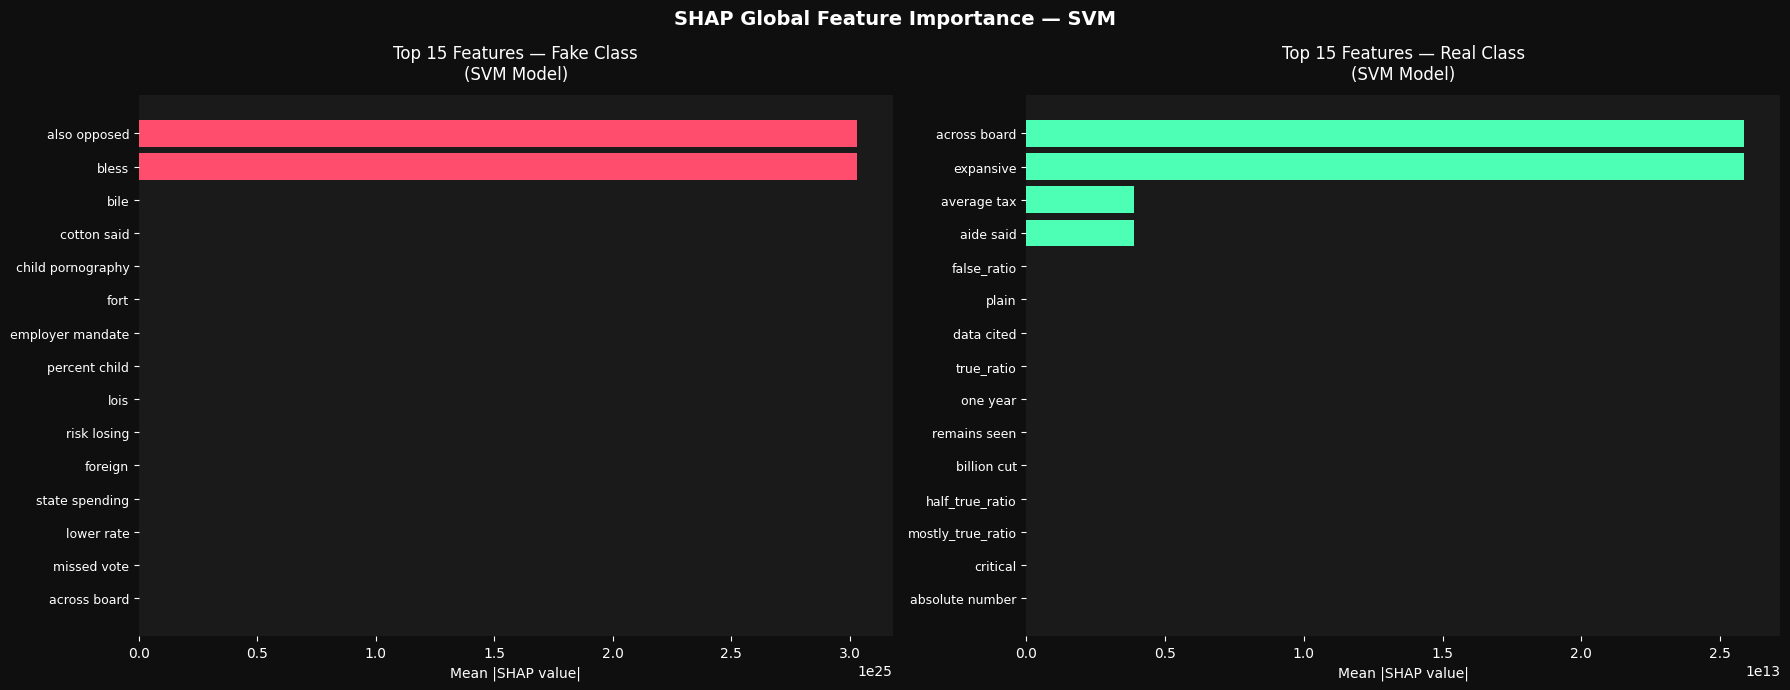

Saved as demo_shap_summary.png


In [6]:
# ============================================================
# BLOCK 6 — SHAP Feature Importance Summary
# ============================================================
# Shows the global feature importance learned by the SVM
# based on the 200 pre-computed SHAP explanations

tfidf_feature_names = tfidf.get_feature_names_out().tolist()
meta_feature_names  = [
    'true_ratio', 'mostly_true_ratio',  'half_true_ratio',
    'mostly_false_ratio', 'false_ratio', 'pants_on_fire_ratio'
]
all_feature_names = tfidf_feature_names + meta_feature_names

TOP_N          = 15
mean_shap_fake = np.abs(shap_fake).mean(axis=0)
mean_shap_real = np.abs(shap_real).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

# Top features for Fake
ax1 = axes[0]
ax1.set_facecolor('#1a1a1a')
top_fake_idx   = np.argsort(mean_shap_fake)[-TOP_N:]
top_fake_names = [all_feature_names[i] for i in top_fake_idx]
top_fake_vals  = mean_shap_fake[top_fake_idx]
ax1.barh(range(TOP_N), top_fake_vals,
          color='#ff4d6d', edgecolor='none')
ax1.set_yticks(range(TOP_N))
ax1.set_yticklabels(top_fake_names, fontsize=9, color='white')
ax1.set_title(f'Top {TOP_N} Features — Fake Class\n(SVM Model)',
              color='white', fontsize=12, pad=12)
ax1.set_xlabel('Mean |SHAP value|', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_visible(False)

# Top features for Real
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
top_real_idx   = np.argsort(mean_shap_real)[-TOP_N:]
top_real_names = [all_feature_names[i] for i in top_real_idx]
top_real_vals  = mean_shap_real[top_real_idx]
ax2.barh(range(TOP_N), top_real_vals,
          color='#4dffb4', edgecolor='none')
ax2.set_yticks(range(TOP_N))
ax2.set_yticklabels(top_real_names, fontsize=9, color='white')
ax2.set_title(f'Top {TOP_N} Features — Real Class\n(SVM Model)',
              color='white', fontsize=12, pad=12)
ax2.set_xlabel('Mean |SHAP value|', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_visible(False)

plt.suptitle('SHAP Global Feature Importance — SVM',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_shap_summary.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Saved as demo_shap_summary.png")

           FULL MODEL COMPARISON SUMMARY
        Model  Val F1  Test F1  Val F1 (Macro)  Test F1 (Macro)
          SVM  0.8617   0.8684          0.8584           0.8652
Random Forest  0.8416   0.8588          0.8396           0.8568
         LSTM  0.8336   0.8521          0.8295           0.8483
         BERT  0.8638   0.8830          0.8610           0.8805

Best model     : BERT
Best Test F1   : 0.8830
Best Val F1    : 0.8638


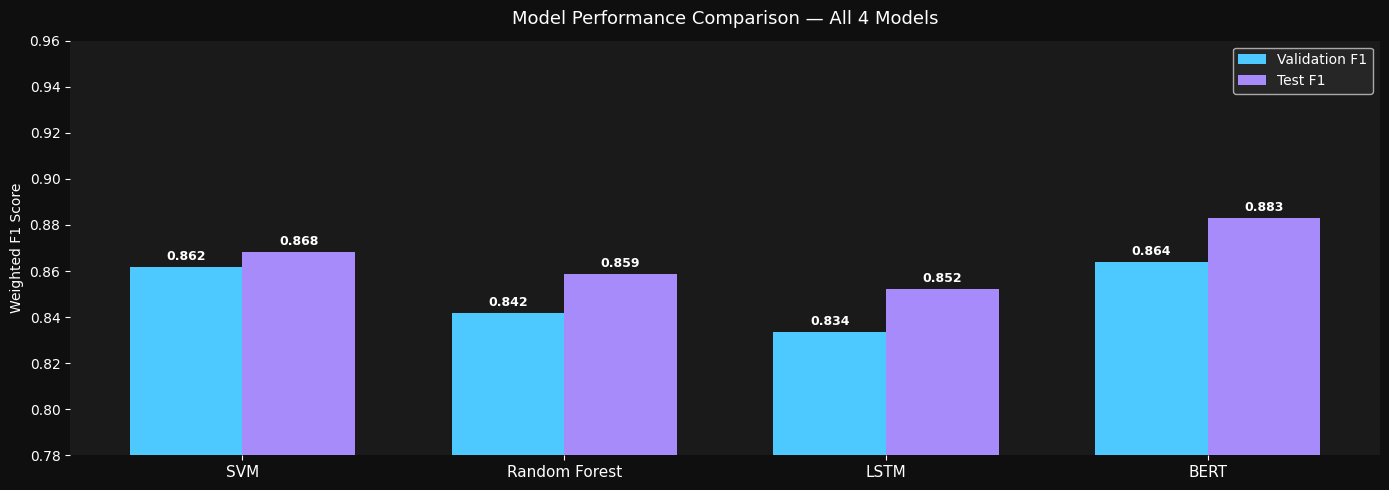

Saved as demo_model_comparison.png


In [7]:
# ============================================================
# BLOCK 7 — Model Performance Summary
# ============================================================
# Hardcoded from your actual training results
# Update if you retrain any model

results_summary = {
    'Model'     : ['SVM', 'Random Forest', 'LSTM', 'BERT'],
    'Val F1'    : [0.8617, 0.8416, 0.8336, 0.8638],
    'Test F1'   : [0.8684, 0.8588, 0.8521, 0.8830],
    'Val F1 (Macro)'  : [0.8584, 0.8396, 0.8295, 0.8610],
    'Test F1 (Macro)' : [0.8652, 0.8568, 0.8483, 0.8805],
}
df_results = pd.DataFrame(results_summary)

print("="*65)
print("           FULL MODEL COMPARISON SUMMARY")
print("="*65)
print(df_results.to_string(index=False))
print("="*65)
print(f"\nBest model     : BERT")
print(f"Best Test F1   : 0.8830")
print(f"Best Val F1    : 0.8638")

# Visual
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

x     = np.arange(len(df_results['Model']))
width = 0.35
bars1 = ax.bar(x - width/2, df_results['Val F1'],  width,
               color='#4dc9ff', label='Validation F1',
               edgecolor='none')
bars2 = ax.bar(x + width/2, df_results['Test F1'], width,
               color='#a78bfa', label='Test F1',
               edgecolor='none')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9,
            color='white', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9,
            color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'],
                    color='white', fontsize=11)
ax.set_ylabel('Weighted F1 Score', color='white')
ax.set_ylim(0.78, 0.96)
ax.set_title('Model Performance Comparison — All 4 Models',
             color='white', fontsize=13, pad=12)
ax.legend(facecolor='#2a2a2a', labelcolor='white')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.show()